
## STOCHASTIC MODELING
MODULE 7 | LESSON 4


---

# **TRADING STRATEGY USING REINFORCEMENT LEARNING**

|  |  |
|:---|:---|
|**Reading Time** |  60 min |
|**Prior Knowledge** |Markov process, Optimization, Monte Carlo  |
|**Keywords** |Reinforcement learning, multi-armed bandits


---

*In this lesson, we develop a fully fledged financial application of RL. We are going to apply RL in a trading strategy for Facebook stock.*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.random import rand, seed

## 1. **Optimal Trading Behavior on META Stock from Reinforcement Learning**

As an end to this module and the concepts of reinforcement learning, we are going to apply the Q-learning algorithm to model and approximate an investor's optimal trading choices in the context of a single stock, in this case META, formerly Facebook (FB). Our objective with this example is to train an RL algorithm during a training sample and then test its performance out of sample.

We first upload the information on META's stock price at a daily frequency over a five-year span, from July 2017 to July 2022. We are going to focus on closing prices, abstracting from intraday variation. 

Feel free, after reviewing and understanding this implementation, to exploit information about any other asset and test the workings of the architecture we develop below. Moreover, as we navigate through the example, you will notice that we will make several assumptions to make the problem manageable for this course. You may also discover how overcoming those assumptions may increase the efficiency of the algorithm.


In [2]:
ticker = "META"  # 'KO' #

# Read data
PData = pd.read_csv(ticker + ".csv")

YDatapd = PData[["Adj Close"]]
YData = YDatapd.to_numpy()

RData = (YData[1 : YData.shape[0] - 1] - YData[0 : YData.shape[0] - 2]) / YData[
    0 : YData.shape[0] - 2
]

YData_dates = pd.to_datetime(PData["Date"], format="%Y-%m-%d")

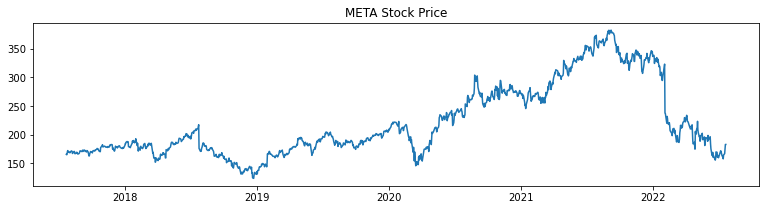

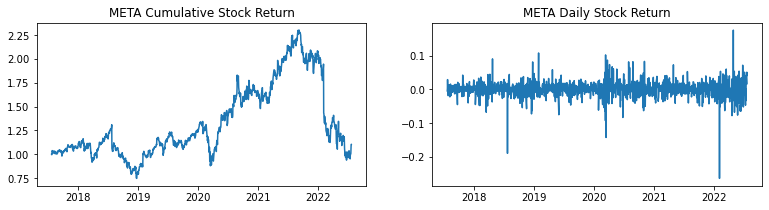

2022-01-03 00:00:00 [338.540009]


In [3]:
plt.plot(YData_dates, YData)
plt.title(ticker + " Stock Price")

fig = plt.gcf()
fig.set_size_inches(13, 3)
plt.show()

plt.subplot(1, 2, 1)
plt.plot(YData_dates, YData / YData[0])
plt.title(ticker + " Cumulative Stock Return")
plt.subplot(1, 2, 2)
plt.plot(YData_dates[1 : len(YData_dates) - 1], RData)
plt.title(ticker + " Daily Stock Return")

fig = plt.gcf()
fig.set_size_inches(13, 3)
plt.show()

print(YData_dates[1120], YData[1120])

Notice the relatively "stable" pattern in META's stock price until 2020, oscillating in an interval of +/- 25 percent from the price at the beginning of the period. After that, in line with the general developments in stock markets after COVID-19, the stock price more than doubled from the July 2017 benchmark. In contrast, since late 2021, META's stock price experienced a great adjustment, in association with the general stock market developments in high-tech companies but also related to revisions of the company's forecasts. In 2022, the stock price at the end of the period returned to levels of the beginning of the sample in 2017. <span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

### **1.1 Ingredients of the Model**

We are going to model an agent (the investor) that must take actions (trading decisions) based on an objective of wealth maximization with risk aversion considerations. The agent starts with some initial cash $c_0$ that can be allocated to purchasing stock of META during some time period. The time steps $t=0,1,2...,T$ are days, where $T$ is a fixed investment horizon in which the investor liquidates the position. 

Let $n_t$ denote the number of shares owned by the investor at the beginning of day $t$ and $p_t$ the corresponding closing stock price. Then, the expression $n_{t+1}-n_t$ denotes the number of shares purchased (if positive) or sold (if negative) in day $t$. We abstract from the investor taking short positions or using leverage, i.e., $n_t\geq0$ and $c_t\geq0$ for all $t$. We also assume that the investor cannot purchase more than $\overline{n}>0$ shares. 

We assume that the investor must pay a transaction cost of $k>0$ per each share traded in each day. Therefore, the dynamics of the investor's cash balance $c_t$ between day $t$ and day $t+1$ are given by
$$
\begin{align}
c_{t+1} = c_t - p_t(n_{t+1}-n_t) - k |n_{t+1}-n_t|
\end{align}
$$
That is, the investor's cash balance at the beginning of the following day will be equal to the previous cash balance, minus (plus) the purchases (sales) of stock, minus the transaction costs incurred, regardless of trades being purchases or sales.

The value of the investor's wealth at the beginning of time step (day) $t+1$ is just the sum of the cash balance and the market value of the investor's position on META:
$$
\begin{align}
w_{t+1} = c_{t+1} + p_tn_{t+1}
\end{align}
$$
We are going to allow the investor to be risk averse. Specifically, the investor's goal is to maximize "utility" over their terminal wealth:
$$
\begin{align}
U = \frac{w^{1-\sigma}-1}{1-\sigma}
\end{align}
$$
where $\sigma \geq 1$ is a direct measure of the investor's risk aversion. Formally, the utility function above receives the name of Constant Relative Risk Aversion (CRRA); it is widely used in finance and you may have already studied it in other finance courses. When $\sigma=1$, the previous function becomes $U = \ln w$. With this formulation, the investor will be wary of trading decisions that have large upside gains and downside losses (i.e., highly volatile). We also assume that the investor has a discount parameter $\gamma\in(0,1)$.

While the investor plans to maintain their trading activity up to date $T$, we allow for additional terminal states. First, if the investor's cash balance turns negative, the investor stops trading and incurs a penalty $\tau |c_t|$ that captures fees and charges for having a negative balance. Second, the investor will be happy enough to stop trading when they reach an accumulated gross return of $\overline{R}$. Similarly, the agent will stop trading when they have accumulated a gross return below $\underline{R}\lt1$. That is, the terminal conditions are $c_t\lt0$, $w_t/c_0>\overline{R}$, and $w_t/c_0\lt\underline{R}$. These terminal conditions will be useful to allow the Q-learning algorithm to learn about different outcomes across the state space. The terminal utility of the agent at any of these terminal situations will be equal to the utility of the wealth obtained at that point, minus the corresponding penalty when the cash balance is negative.

### **1.2 The Investor's Problem**

The state space of the model is given by a vector $s_t=(p_t,n_t,c_t)$ that tells us the current price of META's stock, the number of shares held by the investor at the end of the previous time step, and the investor's cash balance at the end of the previous day. The action space is a discrete choice $n_t\in\{0,1,2,...,\overline{n}\}$. If we exploit the state-action function $Q(s_t,a_t)$ we can formulate the optimization problem of the investor as:
$$
\begin{align}
Q(s_t,a_t) = \gamma \mathbb{E}_{s_{t+1}|s_t}\underset{a}{\max} Q(s_{t+1},a)
\end{align}
$$
where $Q(s_t,a)=U_{terminal}$ whenever we reach a terminal state, and $\mathbb{E}$ denotes the expectation operator. Notice that the dynamics of the state arise from the law of motion for $c_t$ as stated above, the investor's optimal action for $n_t$ in the previous time step, and the price dynamics, which are a given to us.

### **1.3 Setting up the Model Parameters**

We fix the investor's initial cash to \$10,000, while they will be happy to stop trading after doubling their initial wealth. They will also stop trading in case they reach losses of more than 50 percent.

We set the pecuniary penalty of entering into negative cash $\tau$ to 1.25, the transaction cost $k$ to 0.25, the discount parameter $\gamma$ to 0.9975, and the risk aversion $\sigma$ to a level of 2. We also set the maximum number of shares to be purchased $\overline{n}$ equal to $45$, and create a grid of share holdings bounded by zero and $\overline{n}$.

In [4]:
INIT_CASH = 10000
MIN_WEALTH = INIT_CASH * 0.5
MAX_WEALTH = INIT_CASH * 2

PENALTY = 1.25
COST = 0.25  # transaction cost k
GAMMA = 0.9975
SIGMA = 2

A = 46  # Number of actions
AGRID = np.linspace(0, A - 1, A)

### **1.4 Discretization of the State Space**

One issue that we face is that the realizations of stock prices and cash in the state space are continuous. To solve this, we are going to discretize the state space by creating grids with discrete realizations of prices and cash. 

If it turns out that either of the realizations of prices or cash are not in grid, we are going to opt for the simplest nearest-neighbor interpolation scheme. That is, suppose that we need to approximate the value of a function at point $s_a$ and we have the values of a function $f(s)$ for grid points $S=\{s_0,s_1,...,s_N\}$. Then, we approximate the function $f$ at $s_a$ by $\widehat{f}(s_a)=f(min \{s\in S\}: s>s_a)$. Obviously, there exist much better approximation solutions out there. A popular strategy is to embed a neural network in the RL setup to obtain approximations to the optimization objects. Still, let's see how far we can get with the simplest algorithm.

We set up two grids of 200 points for each of the realizations of stock prices and cash. The grid for stock prices is bounded by the minimum and maximum price realizations in the period. We set the bounds for cash at 80 percent below the minimum wealth required and 20 percent above the maximum wealth target.

In [5]:
N = 200
PGRID = np.linspace(np.min(YData), np.max(YData), N)
CGRID = np.linspace(0.8 * MIN_WEALTH, MAX_WEALTH * 1.2, N)

### **1.5 Training and Test Sample**

Before proceeding with the explicit development of the RL algorithm, we need to set up a training and a test sample. That is, we are going to train and optimize the decision-making of the investor for some time period and then check the performance when we bring in new information for the agent.

As a training sample, we use the sample period until December 2021. We use as a test sample the period from January to July 2022. If you run the block of code below, you will notice that the test sample is quite a challenging period to evaluate the algorithm, given the steep drop of META's stock price.

One important caveat here is that our function approximation method constrains our choice of training and test samples. To see this, suppose that we decide to split our samples around some date in 2020. Many of the stock price realizations after that date would be outside of the range of META's stock prices in the training sample. This means that the algorithm would be unable to prescribe an accurate optimal policy. In that case, we would need to apply more sophisticated function approximations that allow for evaluating our functions outside of the range of values considered in the training sample.

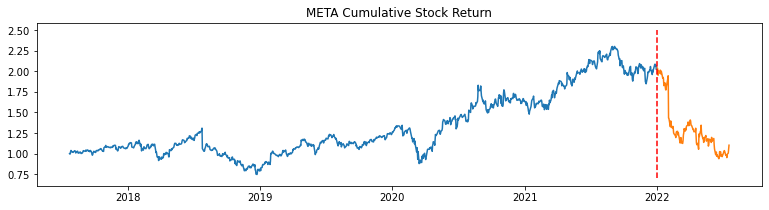

In [6]:
TTRAIN = 1120

plt.plot(YData_dates[0:TTRAIN], YData[0:TTRAIN] / YData[0])
plt.plot(
    YData_dates[TTRAIN : len(YData) - 1], YData[TTRAIN : len(YData) - 1] / YData[0]
)
plt.title(ticker + " Cumulative Stock Return")
plt.plot([YData_dates[TTRAIN], YData_dates[TTRAIN]], [0.7, 2.5], "r--")

fig = plt.gcf()
fig.set_size_inches(13, 3)
plt.show()

### **1.6 Optimization Algorithm**

After introducing the setup and fixing the parameters of the model, we can now turn to solve it. We are going to opt for a Q-learning algorithm. Recall that the updating of the state-action value function is of the form:
$$
\begin{align*}
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\big[r_t + \gamma \underset{a}{\max}Q(s_{t+1},a) - Q(s_t,a_t) \big]
\end{align*} 
$$
We now initialize our optimization objects, state-action value, and policy functions. We also set to 16,000 the number of episodes where the agent is going to repeatedly face the actual realizations of META's stock prices at each time step. We fix the updating parameter $\alpha$ to 0.4. We split the episodes in three samples that differ in the randomness of $\varepsilon$-greedy policies. In the initial episodes, the agent will opt for a greedy policy only 90 percent of the time, next 95 percent, while in the last 1,000 episodes we will refine the optimal policies by always opting for the greedy action.

To evaluate the performance of the algorithm in the training sample, we are going to create an array that will store, for each episode, the agent's terminal wealth.

In [7]:
qvalue = np.zeros((N, N, A, A))
policy = np.zeros((N, N, A))

EPISODES = 16000

ALPHA = 0.4
EPISODE_SPLIT = 9000

EPSILON_M = [0.1, 0.05]

terminal_wealth = np.zeros((EPISODES))

The next block of code specifies functions for the $\varepsilon$-greedy policy, the policy improvement step, and the utility function. Notice that in case of ties, the policy improvement determines randomly which action to take in the update.

In [8]:
def e_greedy_investor(nactions, actions, pol, eps, randnum1, randnum2):
    if randnum1 < eps:
        action1 = np.where((nactions - 1) * randnum2 < actions)[0][0]
    else:
        action1 = pol
    return action1


def improve_policy_investor(qval, randnum1):
    pol_list = np.where(qval == np.max(qval))
    # Break ties randomly to determine optimal policy
    if pol_list[0].shape[0] > 1:
        for aa in range(pol_list[0].shape[0]):
            if randnum1 < (aa + 1) / pol_list[0].shape[0]:
                break
        pol = aa
    else:
        pol = np.argmax(qval)
    return pol


def investor_utility(wealth, riskav):
    return (wealth ** (1 - riskav) - 1) / (1 - riskav)

The next block of code implements the Q-learning algorithm to find the optimal trading decisions. When you run the code, plots will appear that indicate the average terminal wealth reached across the most recent episodes (set by the parameter WINDOW). This measure is useful to understand how the algorithm is succeeding or not in finding actions that maximize the terminal utility of the agent. However, notice that computing the terminal wealth is not enough to understand the effectiveness of the algorithm, since a high level of wealth can be linked to, ex ante, too risky trading decisions. 

Notice how the behavior of the algorithm changes as we shift the parameter $\varepsilon$. It is going to take a while, so sit back and relax...

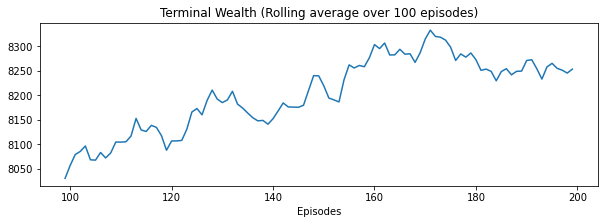

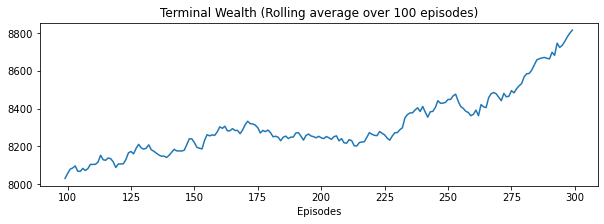

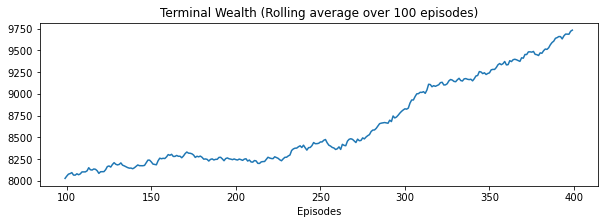

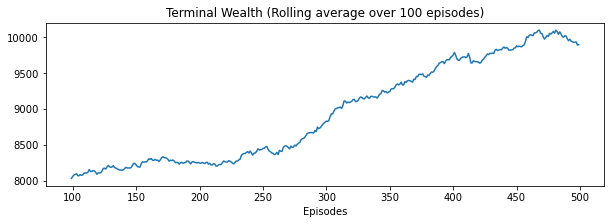

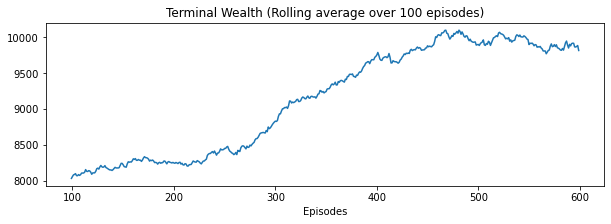

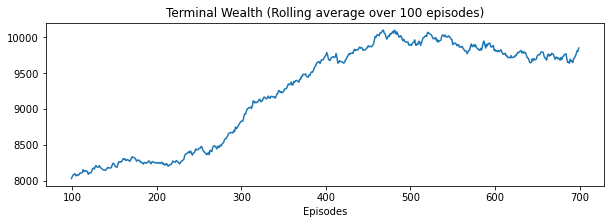

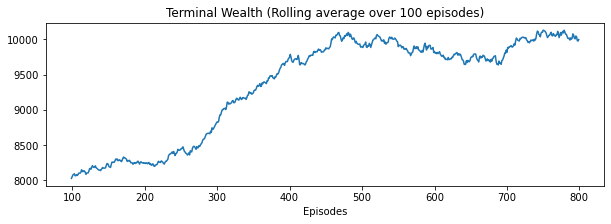

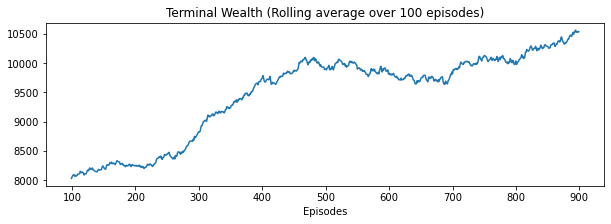

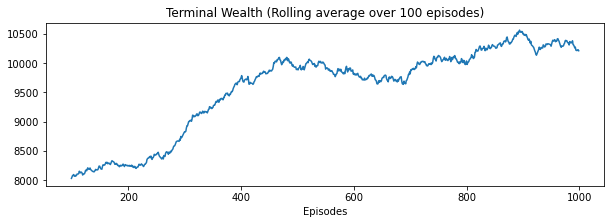

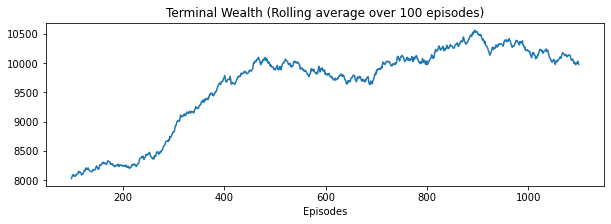

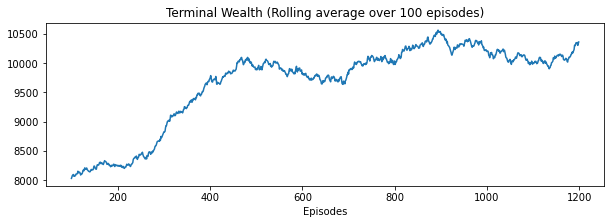

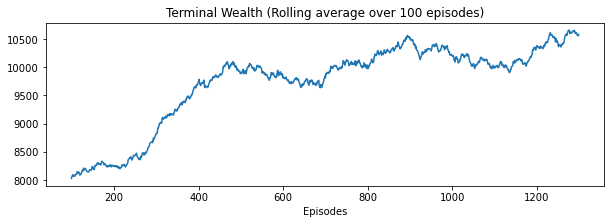

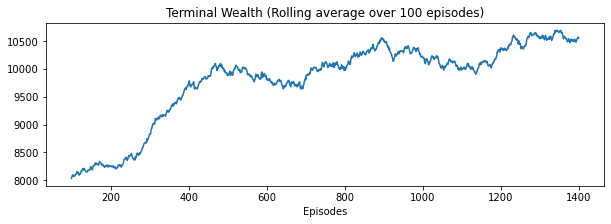

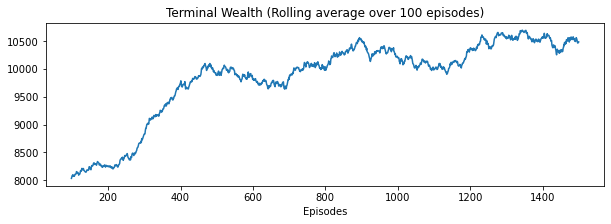

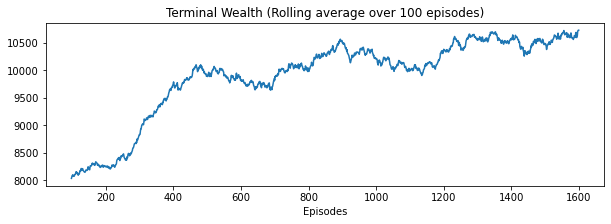

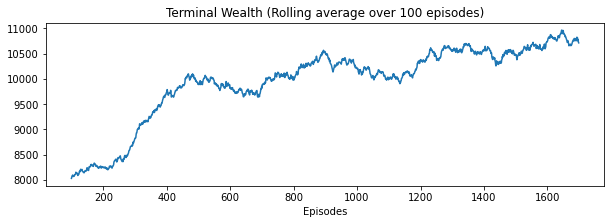

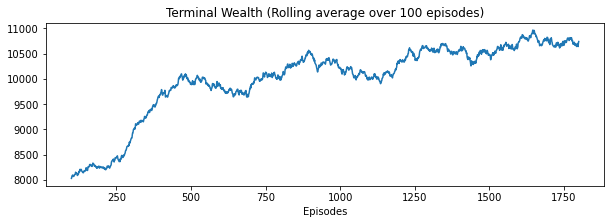

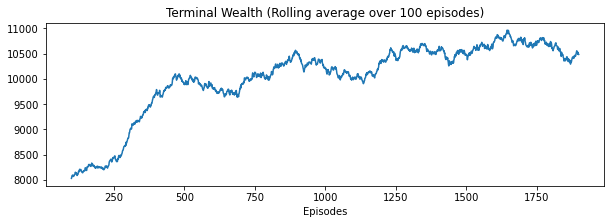

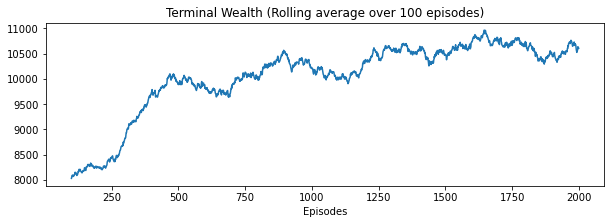

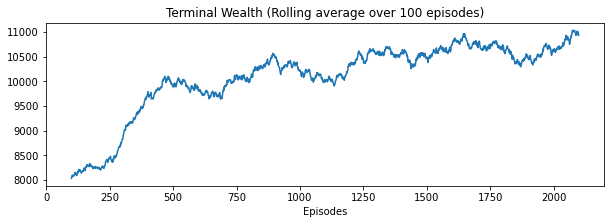

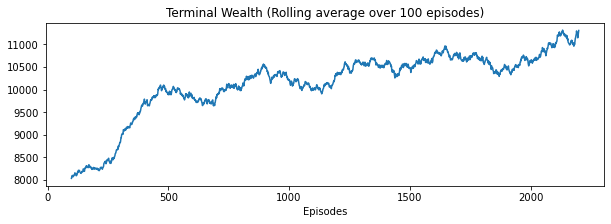

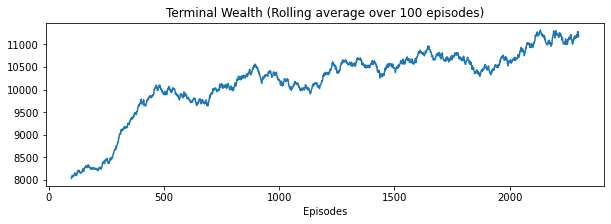

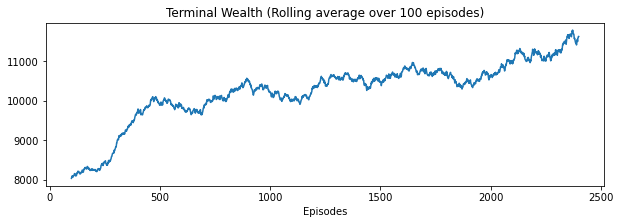

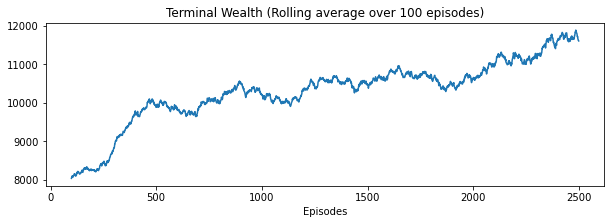

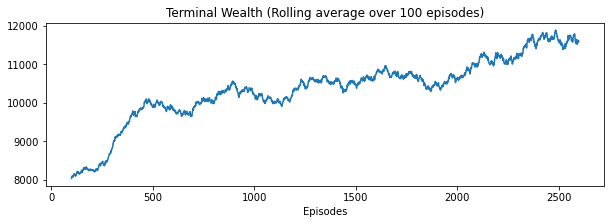

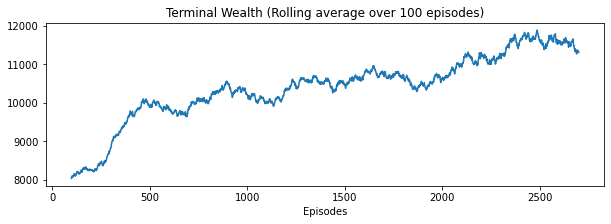

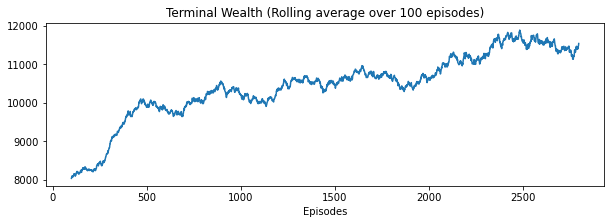

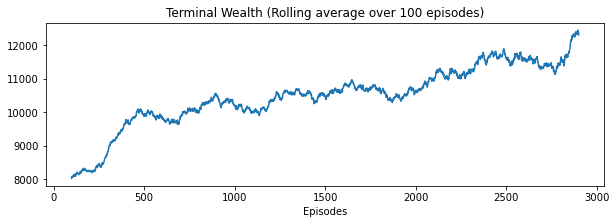

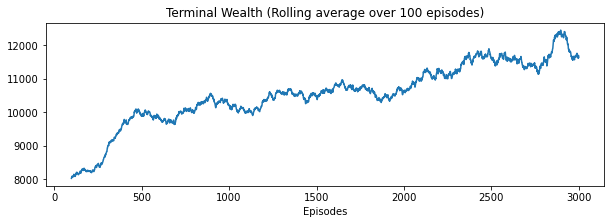

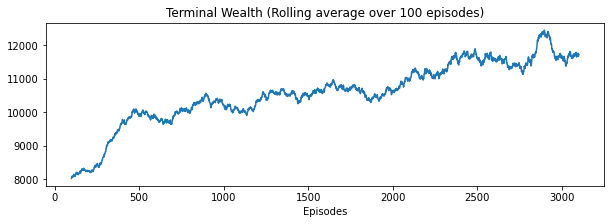

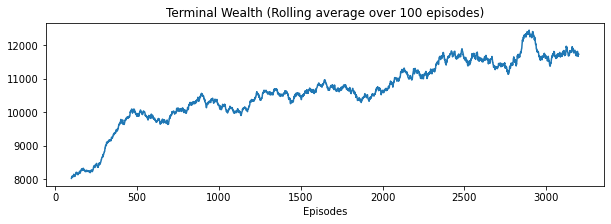

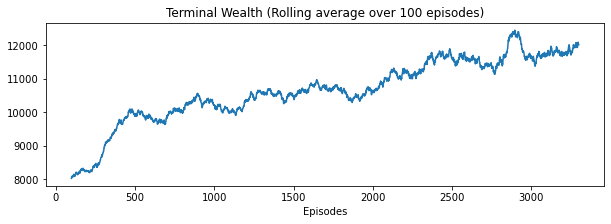

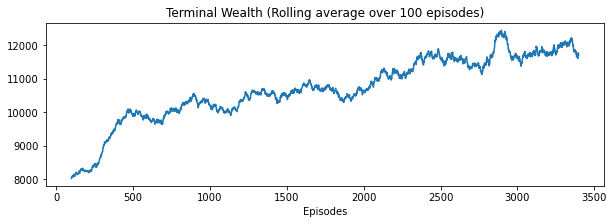

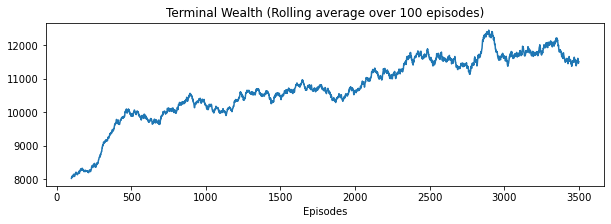

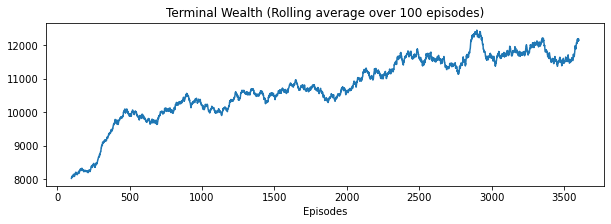

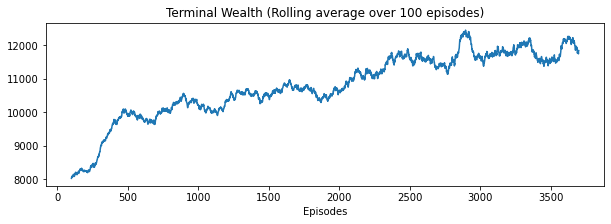

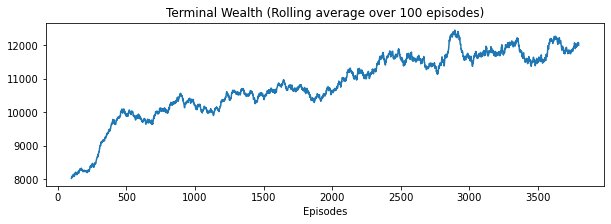

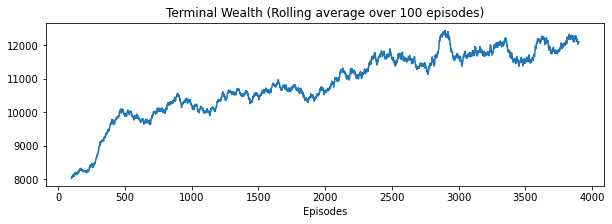

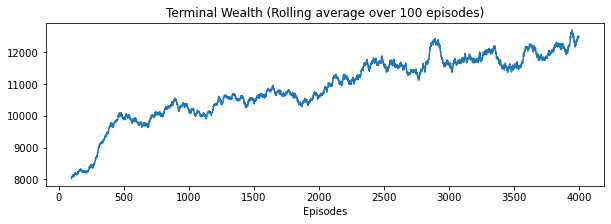

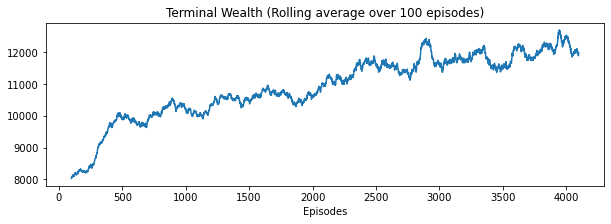

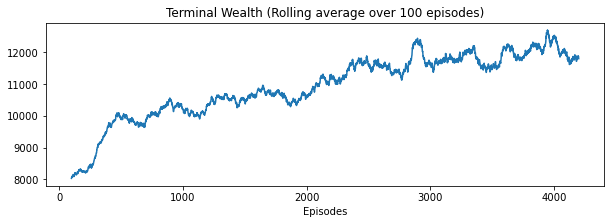

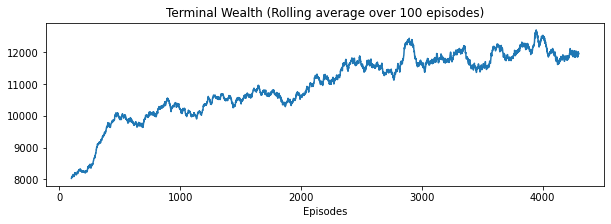

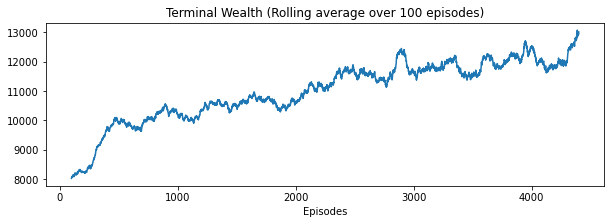

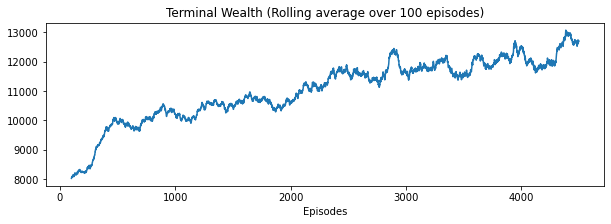

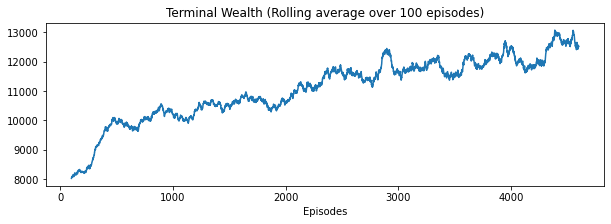

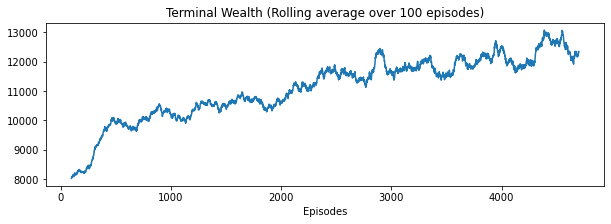

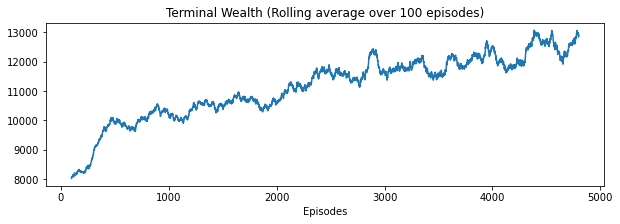

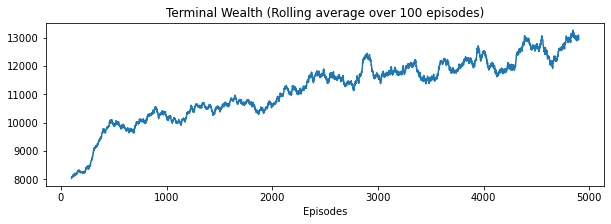

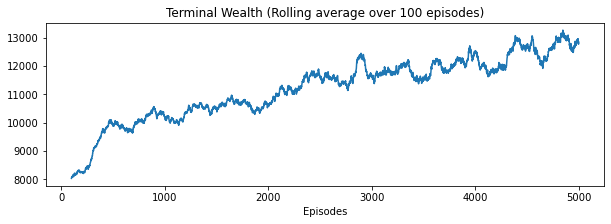

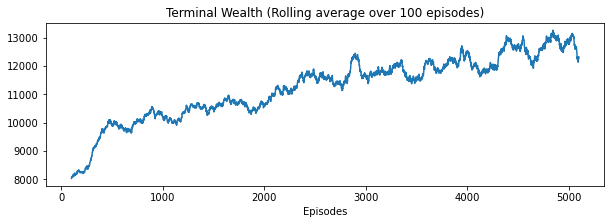

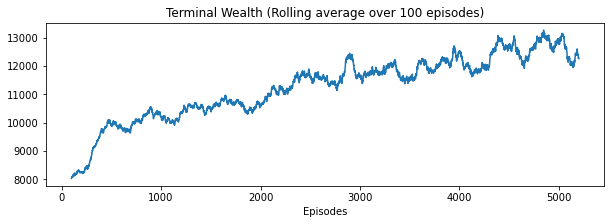

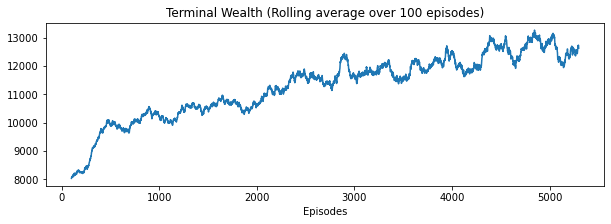

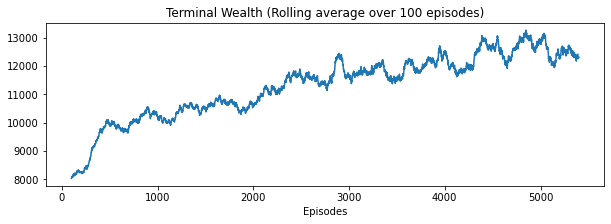

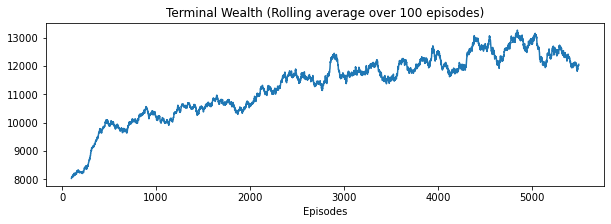

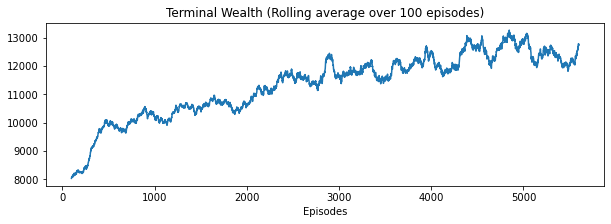

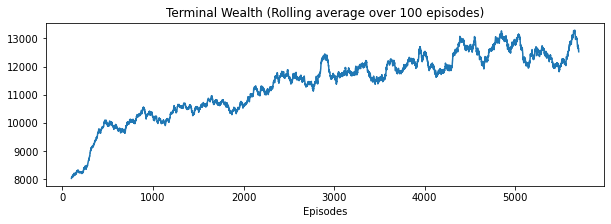

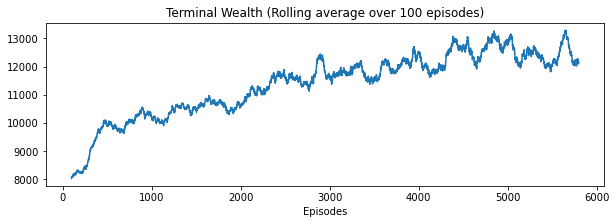

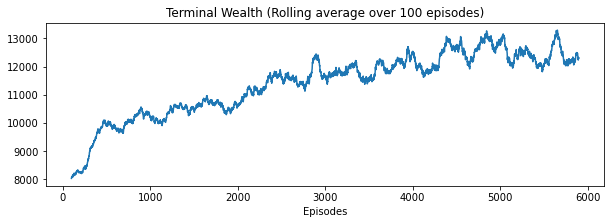

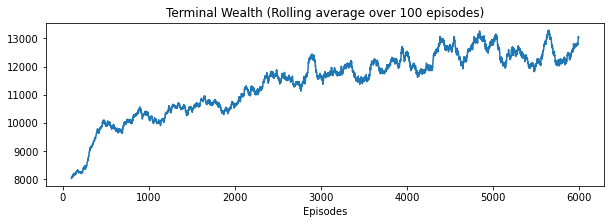

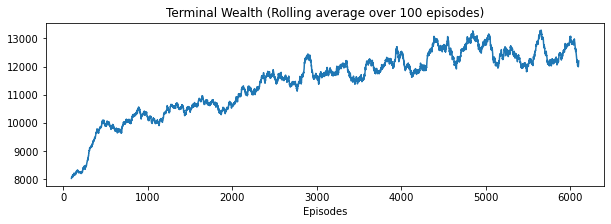

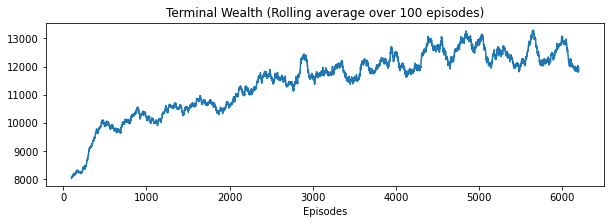

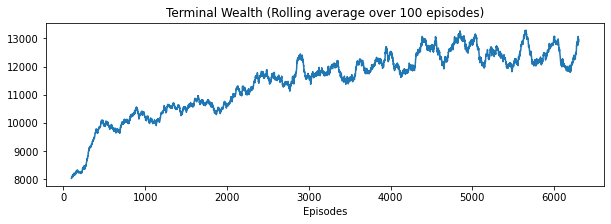

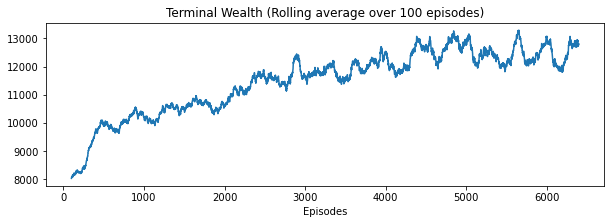

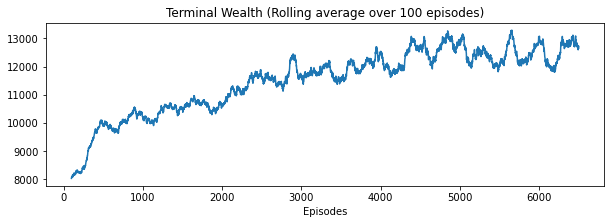

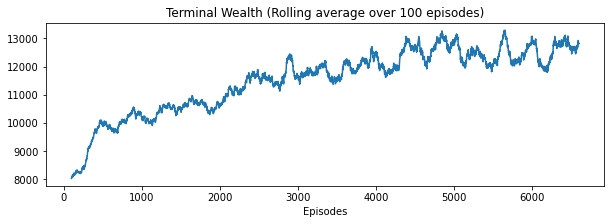

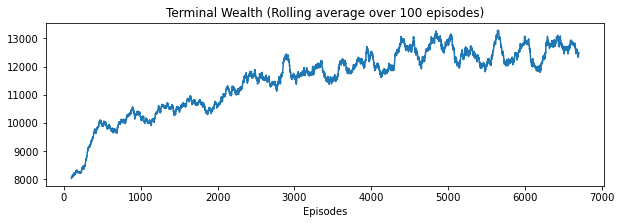

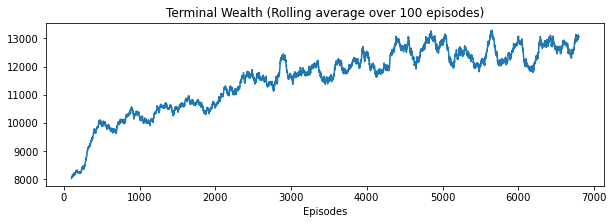

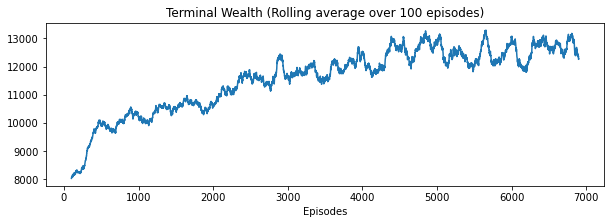

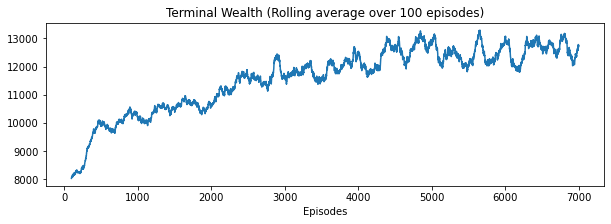

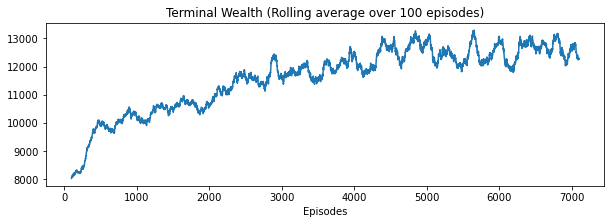

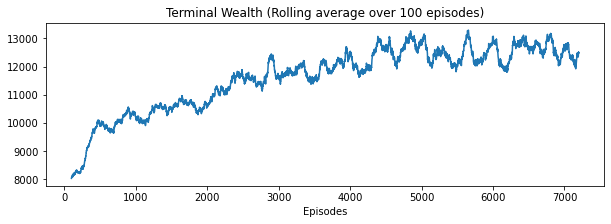

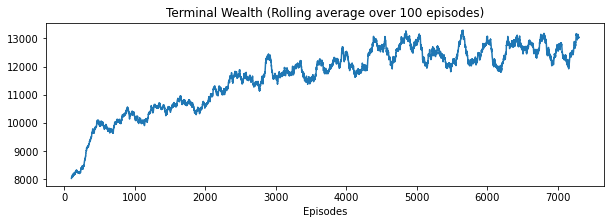

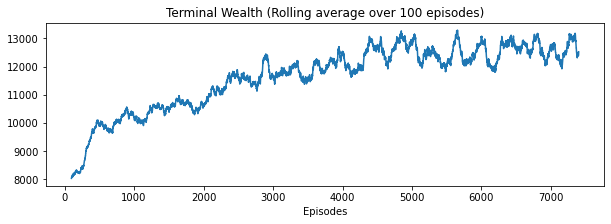

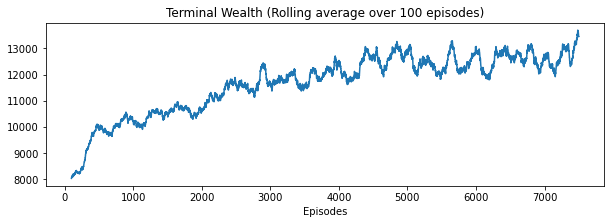

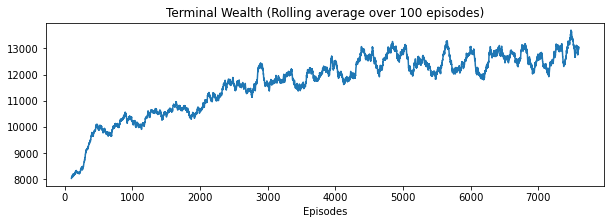

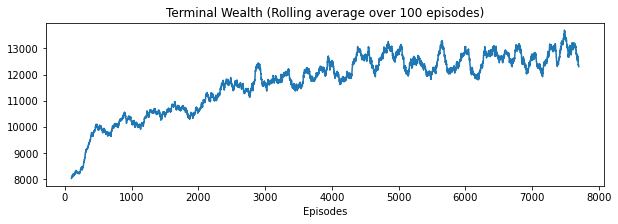

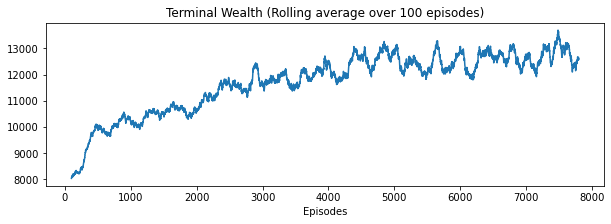

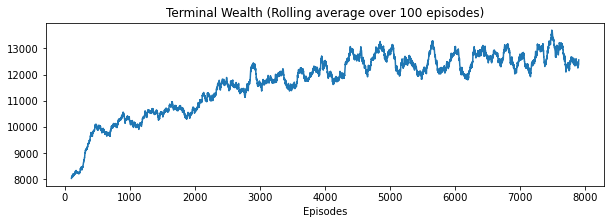

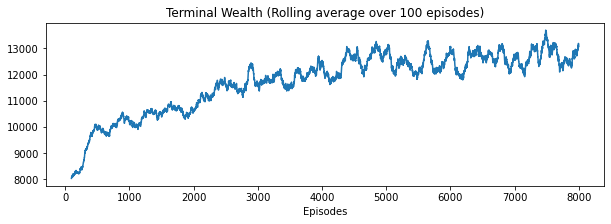

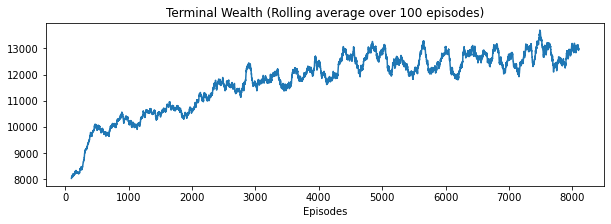

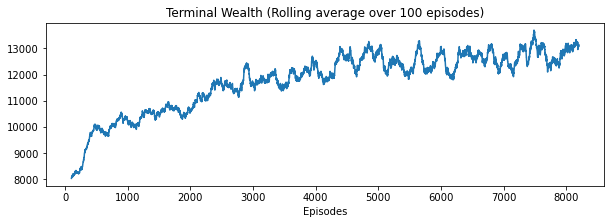

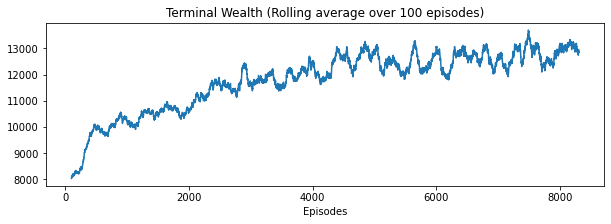

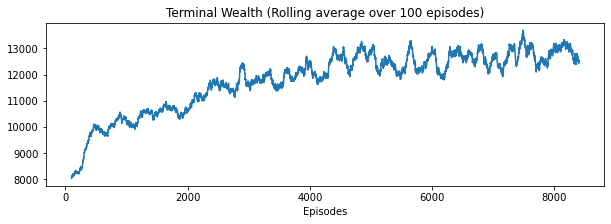

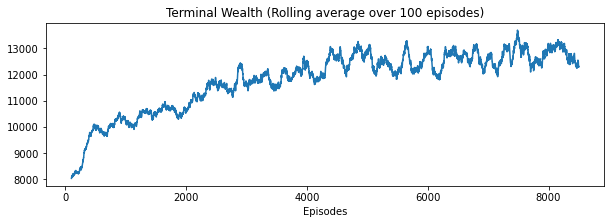

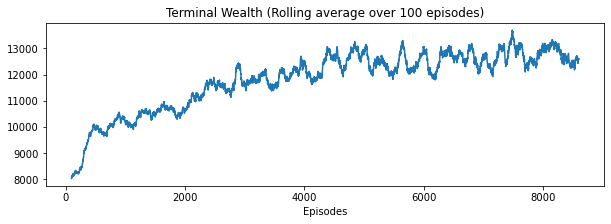

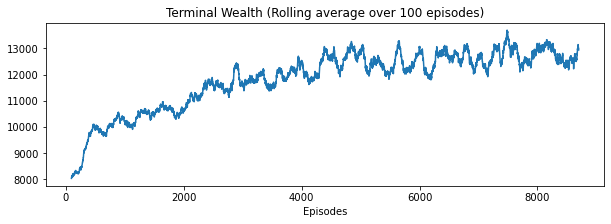

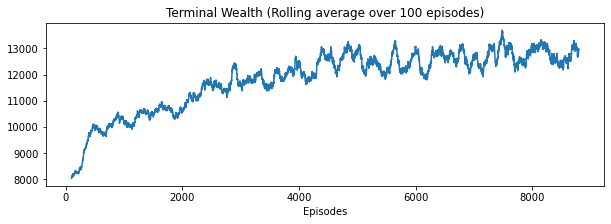

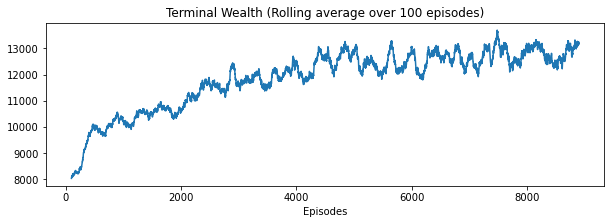

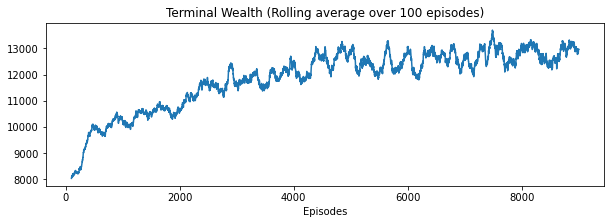

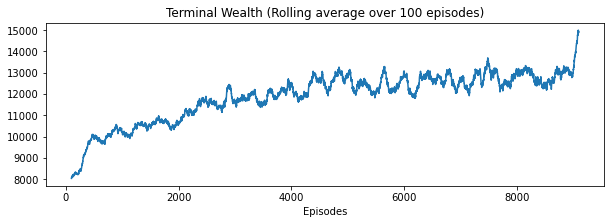

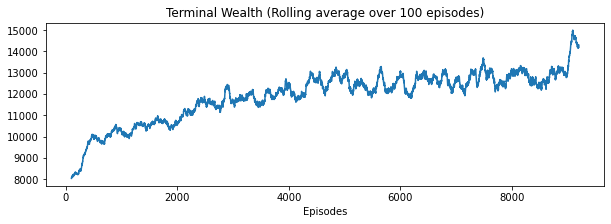

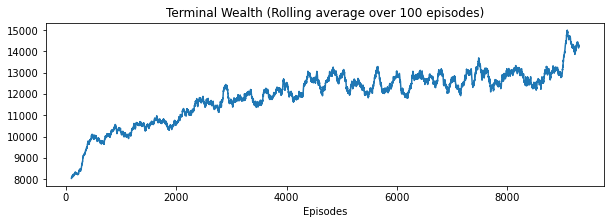

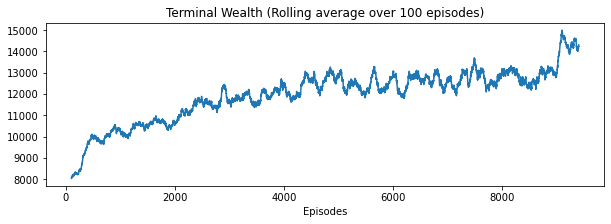

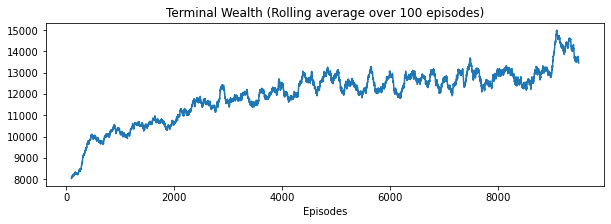

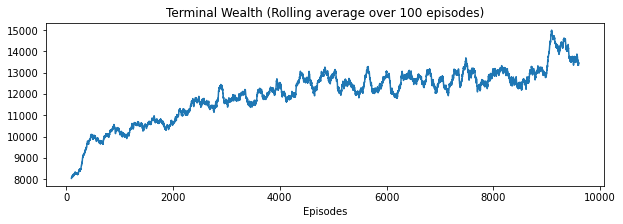

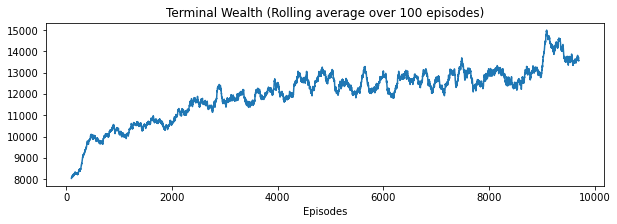

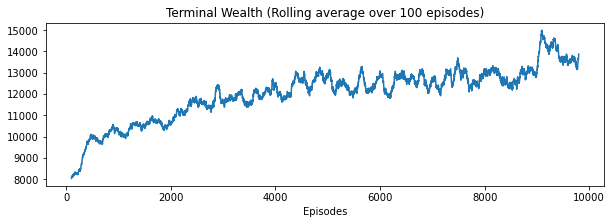

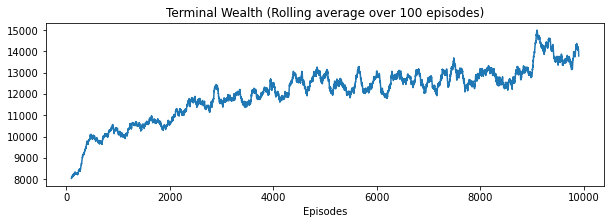

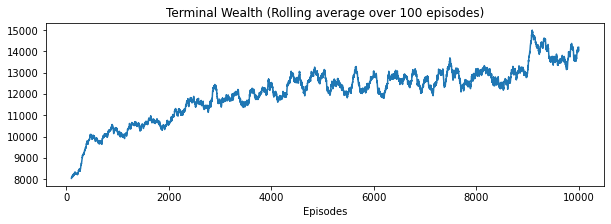

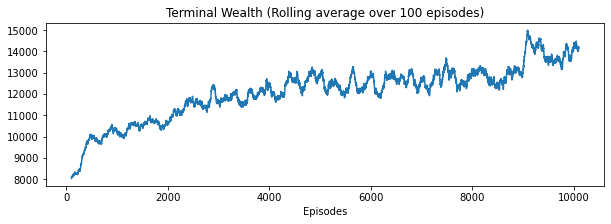

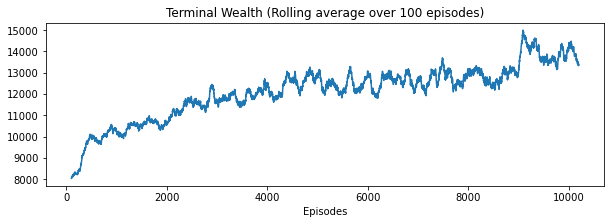

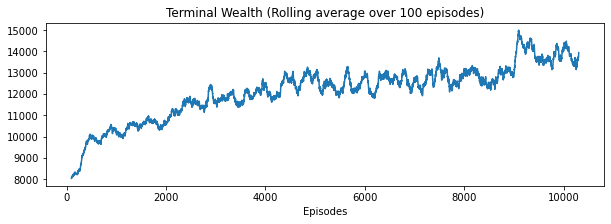

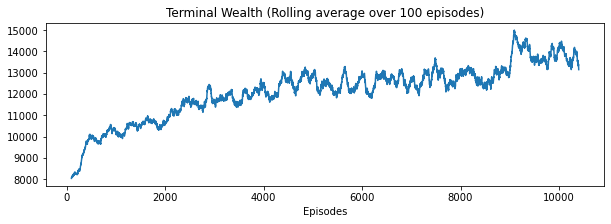

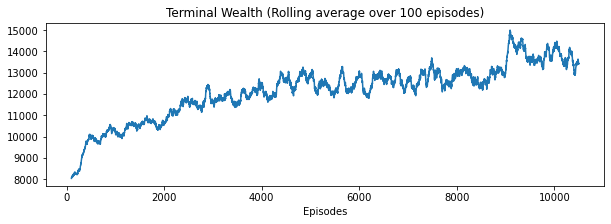

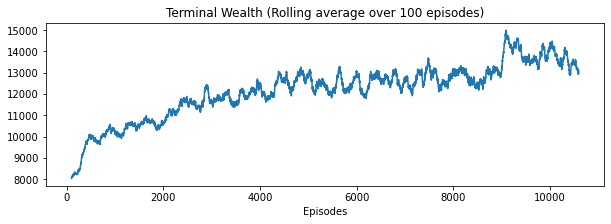

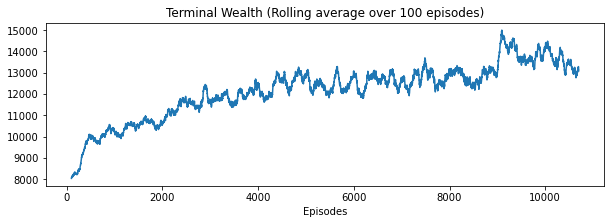

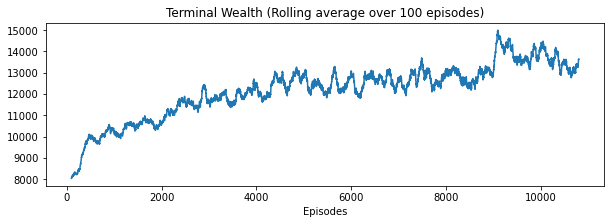

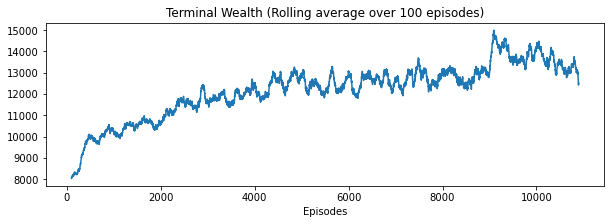

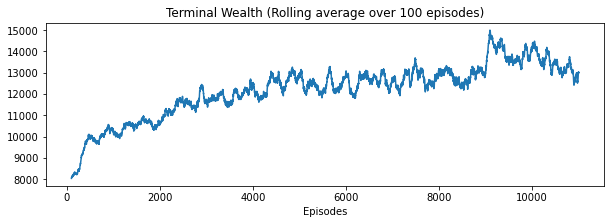

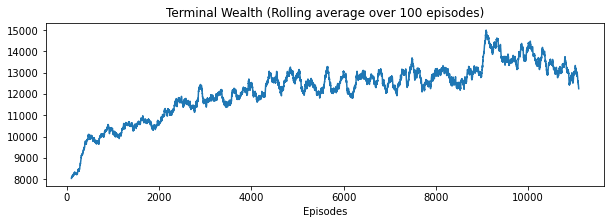

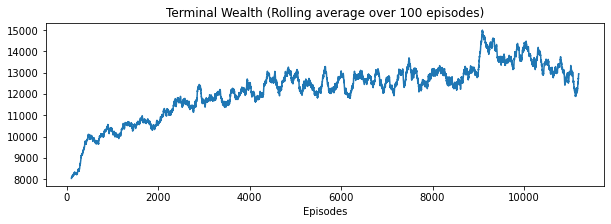

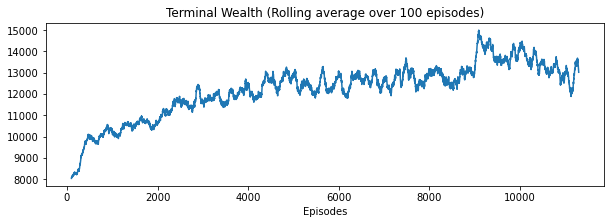

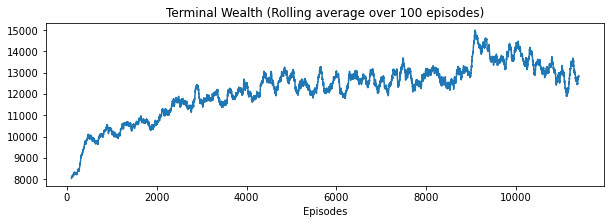

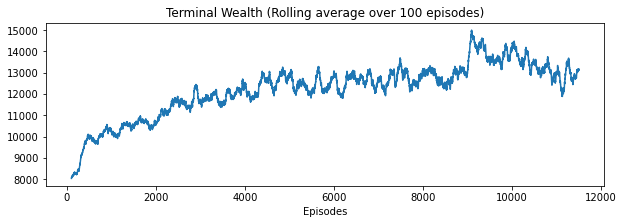

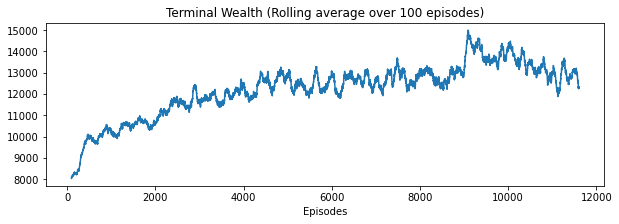

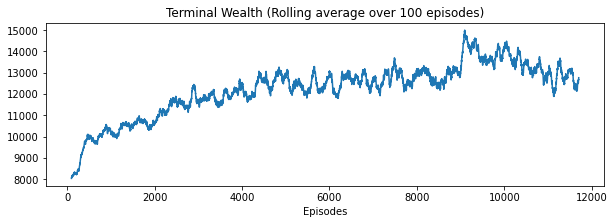

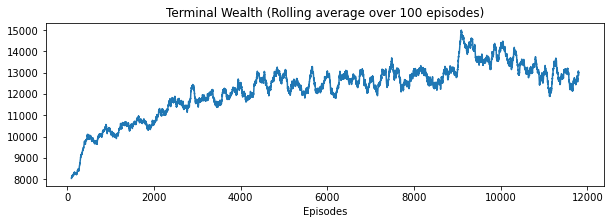

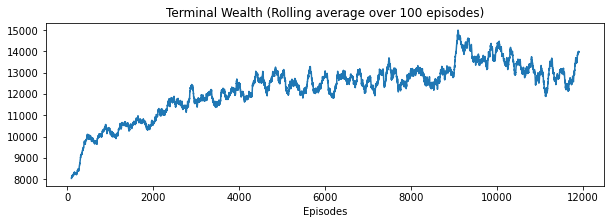

KeyboardInterrupt: 

In [9]:
WINDOW = 100  # Parameter for plotting

seed(1234)

for episode in range(EPISODES):
    # Find the location of price and cash levels
    ss0_loc = np.where(PGRID >= YData[0])[0][0]
    cash0_loc = np.where(CGRID >= INIT_CASH)[0][0]
    # Determine initial cash and actions (assume no holdings)
    cash0 = CGRID[cash0_loc]
    action0 = 0

    # Choose the e-greedy action parameter
    if episode < EPISODE_SPLIT:
        epsilon = EPSILON_M[0]
    elif episode < EPISODES - 1000:
        epsilon = EPSILON_M[1]
    else:
        epsilon = 0.0

    for tt in range(TTRAIN):
        # e-greedy policy to choose a
        action1 = e_greedy_investor(
            A, AGRID, policy[ss0_loc, cash0_loc, action0], epsilon, rand(), rand()
        )
        action1 = int(action1)

        # Terminal states: 1. Reaching MAX_WEALTH, 2. End of training sample
        #                 3. Reaching MIN_WEALTH, 4. Negative cash balance
        if (
            cash0 + PGRID[ss0_loc] * action0 >= MAX_WEALTH
            or tt == TTRAIN - 1
            or cash0 + PGRID[ss0_loc] * action0 < MIN_WEALTH
            or cash0 < 0
        ):
            # Reward is the terminal utility
            terminal_wealth[episode] = (
                cash0 + action0 * YData[tt] - PENALTY * np.abs(cash0) * (cash0 <= 0)
            )
            reward = investor_utility(terminal_wealth[episode], SIGMA)
            # Update Q-function
            qvalue[ss0_loc, cash0_loc, action0, action1] += ALPHA * (
                reward - qvalue[ss0_loc, cash0_loc, action0, action1]
            )
            # Plot the evolution of terminal wealth with the passage of episodes
            if episode > WINDOW and episode % 100 == 0:
                average_w = []
                for ind in range(episode - WINDOW + 1):
                    average_w.append(np.mean(terminal_wealth[ind : ind + WINDOW]))
                for ind in range(WINDOW - 1):
                    average_w.insert(0, np.nan)
                plt.plot(average_w)
                plt.xlabel("Episodes")
                plt.title("Terminal Wealth (Rolling average over 100 episodes)")
                fig = plt.gcf()
                fig.set_size_inches(10, 3)
                plt.show()
            break
        # Non-Terminal states
        elif tt < TTRAIN - 1:
            # given action a, determine next period's initial cash
            cash1 = (
                cash0
                + PGRID[ss0_loc] * (action0 - action1)
                - COST * np.abs(action0 - action1)
            )
            cash1_loc = np.where(CGRID >= cash1)[0][0]
            # determine position of next period's stock price
            ss1_loc = np.where(PGRID >= YData[tt + 1])[0][0]
            # reward from non-terminal states is zero
            reward = 0
            # Update Q-function
            qvalue[ss0_loc, cash0_loc, action0, action1] += ALPHA * (
                reward
                + GAMMA * np.max(qvalue[ss1_loc, cash1_loc, action1, :])
                - qvalue[ss0_loc, cash0_loc, action0, action1]
            )
            # Improve policy
            policy[ss0_loc, cash0_loc, action0] = improve_policy_investor(
                qvalue[ss0_loc, cash0_loc, action0, :], rand()
            )
            # Update state for next time step
            ss0_loc = ss1_loc
            cash0 = cash1
            cash0_loc = cash1_loc
            action0 = action1

What is the out-of-sample performance of the trading behavior developed from the Q-learning algorithm? To check this, we follow the optimal path for an investor that starts with \$10,000 and continues trading even beyond the end of the training sample.

In [10]:
# Plot time series of price and investor's position
action0 = 0
cash0 = INIT_CASH
state = np.zeros((len(YData), 3))
action = np.zeros((len(YData)))
for tt in range(len(YData)):
    state[tt, 0] = YData[tt]
    state[tt, 1] = cash0
    state[tt, 2] = action0
    ss0_loc = np.where(PGRID >= YData[tt])[0][0]
    cash0_loc = np.where(CGRID >= cash0)[0][0]
    action[tt] = policy[ss0_loc, cash0_loc, action0]
    action0 = int(action[tt])
    cash0 = (
        state[tt, 1]
        + state[tt, 0] * (state[tt, 2] - action[tt])
        - COST * np.abs(state[tt, 2] - action[tt])
    )

Let's investigate how the investor performs over time, even in the unnavigated and stormy period of 2022. To analyze this, we compare the cumulative return of META over the period, that is, the buy-and-hold strategy, with the ratio of accumulated wealth to initial wealth of the strategy that is generated by the Q-learning algorithm. Notice that the latter is net of the corresponding transaction costs involved in the strategy. 

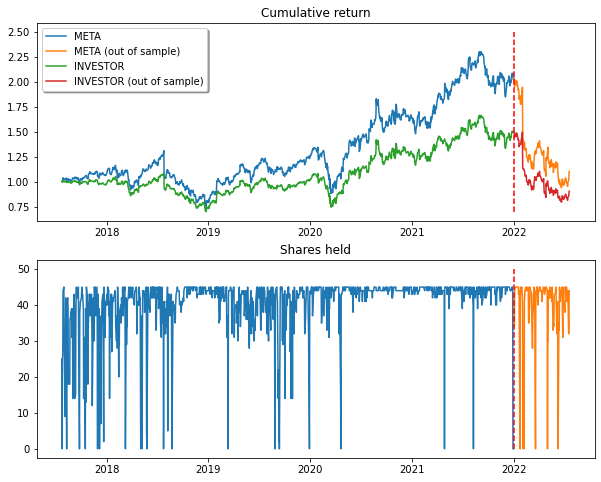

In [11]:
plt.subplot(2, 1, 1)
plt.plot(YData_dates[0:TTRAIN], state[0:TTRAIN, 0] / state[0, 0], label="META")
plt.plot(
    YData_dates[TTRAIN : len(YData) - 1],
    state[TTRAIN : len(YData) - 1, 0] / state[0, 0],
    label="META (out of sample)",
)
plt.plot(
    YData_dates[0:TTRAIN],
    (state[0:TTRAIN, 1] + state[0:TTRAIN, 0] * state[0:TTRAIN, 2]) / state[0, 1],
    label="INVESTOR",
)
plt.plot(
    YData_dates[TTRAIN : len(YData) - 1],
    (
        state[TTRAIN : len(YData) - 1, 1]
        + state[TTRAIN : len(YData) - 1, 0] * state[TTRAIN : len(YData) - 1, 2]
    )
    / state[0, 1],
    label="INVESTOR (out of sample)",
)

plt.plot([YData_dates[TTRAIN], YData_dates[TTRAIN]], [0.7, 2.5], "r--")
legend = plt.legend(loc="upper left", shadow=True)
plt.title("Cumulative return")
plt.subplot(2, 1, 2)
plt.plot(YData_dates[0:TTRAIN], action[0:TTRAIN], label="Training")
plt.plot(
    YData_dates[TTRAIN : len(YData) - 1],
    action[TTRAIN : len(YData) - 1],
    label="Out of sample",
)
plt.plot([YData_dates[TTRAIN], YData_dates[TTRAIN]], [0, 50], "r--")
plt.title("Shares held")

fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.show()

At first, you might think that the investor is underperforming a simple buy-and-hold strategy. However, recall that the investor is risk-averse and wary of large fluctuations in their expected terminal wealth. Indeed, notice from the first graph above that the agent is able to smooth the downside returns of META by giving up on some returns in those periods where the stock price grows. You can verify that in Sharpe ratio terms, the optimized strategy tends to perform as well or even better than the buy-and-hold strategy.

Out of sample, the investor is less exposed to the collapse of the stock price relative to a buy-and-hold strategy, although still suffering large losses. This is natural, given that the algorithm can hardly identify such a jump in the stock price from its past experience. Still, the model above, even in the absence of a full set of fine-tuning, e.g., adding more information for the agent, more sophisticated function approximations, or further adjustments in the learning parameters $\varepsilon$ and $\alpha$, can generate non-catastrophic outcomes.

One major drawback of these RL methods is the apparent lack of transparency, intrinsic to most machine learning methodologies. That is, we cannot distinguish, even with a careful investigation, why the agent lays priority over some actions relative to others in particular states. 

## **2. Conclusion**

In this lesson, we have developed a complete trading strategy based on reinforcement learning algorithms from scratch.


---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
